In [1]:
import pandas as pd
import numpy as np
import os
import time
from catboost import CatBoostRegressor
from xgboost import XGBRegressor 
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_log_error, mean_squared_error
from lightgbm import LGBMRegressor
import optuna

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

In [3]:
def add_feature_cross_terms(df, features):
    df_new = df.copy()
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]
            df_new[f"{f1}_x_{f2}"] = df_new[f1] * df_new[f2]
    return df_new

num_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
train = add_feature_cross_terms(train, num_features)
test = add_feature_cross_terms(test, num_features)

In [4]:
train['Sex'] = train['Sex'].map({'male' : 0, 'female' : 1}).astype('category')
test['Sex'] = test['Sex'].map({'male' : 0, 'female' : 1}).astype('category')

In [5]:
X = train.drop(columns=['id', 'Calories'])
y = np.log1p(train['Calories'])
X_test = test.drop(columns=['id'])

In [6]:
folds = 50
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

In [7]:
oof_cb = np.zeros(len(train))
oof_xgb = np.zeros(len(train))
oof_lgbm = np.zeros(len(train))
pred_cb = np.zeros(len(test))
pred_xgb = np.zeros(len(test))
pred_lgbm = np.zeros(len(test))

In [8]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"CatBoost Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    model_cb = CatBoostRegressor(
        iterations=3000
        , learning_rate=0.02
        , depth=14
        , l2_leaf_reg=0.67
        , cat_features=[X.columns.get_loc('Sex')]
        , loss_function='RMSE'
        , eval_metric='RMSE'
        , early_stopping_rounds=100
    )
    
    model_cb.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
    oof_cb[val_idx] = model_cb.predict(X_val)
    pred_cb += model_cb.predict(X_test)

CatBoost Fold 1


KeyboardInterrupt: 

In [ ]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"XGBoost Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_xgb = XGBRegressor(
        max_depth=10
        , colsample_bytree=0.75
        , subsample=0.9
        , n_estimators=2000
        , learning_rate=0.02
        , gamma=0.01
        , max_delta_step=2
        , enable_categorical=True
        , eval_metric="rmse"
        , early_stopping_rounds=100
        )
    
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=0)
    oof_xgb[val_idx] = model_xgb.predict(X_val)
    pred_xgb += model_xgb.predict(X_test)

XGBoost Fold 1
XGBoost Fold 2
XGBoost Fold 3
XGBoost Fold 4
XGBoost Fold 5
XGBoost Fold 6
XGBoost Fold 7
XGBoost Fold 8
XGBoost Fold 9
XGBoost Fold 10
XGBoost Fold 11
XGBoost Fold 12
XGBoost Fold 13
XGBoost Fold 14
XGBoost Fold 15
XGBoost Fold 16
XGBoost Fold 17
XGBoost Fold 18
XGBoost Fold 19
XGBoost Fold 20
XGBoost Fold 21
XGBoost Fold 22
XGBoost Fold 23
XGBoost Fold 24
XGBoost Fold 25
XGBoost Fold 26
XGBoost Fold 27
XGBoost Fold 28
XGBoost Fold 29
XGBoost Fold 30
XGBoost Fold 31
XGBoost Fold 32
XGBoost Fold 33
XGBoost Fold 34
XGBoost Fold 35
XGBoost Fold 36
XGBoost Fold 37
XGBoost Fold 38
XGBoost Fold 39
XGBoost Fold 40
XGBoost Fold 41
XGBoost Fold 42
XGBoost Fold 43
XGBoost Fold 44
XGBoost Fold 45
XGBoost Fold 46
XGBoost Fold 47
XGBoost Fold 48
XGBoost Fold 49
XGBoost Fold 50
XGBoost Fold 51
XGBoost Fold 52
XGBoost Fold 53
XGBoost Fold 54
XGBoost Fold 55
XGBoost Fold 56
XGBoost Fold 57
XGBoost Fold 58
XGBoost Fold 59
XGBoost Fold 60
XGBoost Fold 61
XGBoost Fold 62
XGBoost Fold 63
X

In [ ]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"LGBM Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_lgbm = LGBMRegressor(
    n_estimators=2000
    , learning_rate=0.02
    , num_leaves=30
    , max_depth=10
    , min_child_samples=20
    , subsample=0.8
    , colsample_bytree=0.8
    , objective='regression'
    , metric='rmse'
    , verbose=-1
    )
    
    model_lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='rmse')
    oof_lgbm[val_idx] = model_lgbm.predict(X_val)
    pred_lgbm += model_lgbm.predict(X_test)

LGBM Fold 1


c:\Users\km154756\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\km154756\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


LGBM Fold 2
LGBM Fold 3
LGBM Fold 4
LGBM Fold 5
LGBM Fold 6
LGBM Fold 7
LGBM Fold 8
LGBM Fold 9
LGBM Fold 10
LGBM Fold 11
LGBM Fold 12
LGBM Fold 13
LGBM Fold 14
LGBM Fold 15
LGBM Fold 16
LGBM Fold 17
LGBM Fold 18
LGBM Fold 19
LGBM Fold 20
LGBM Fold 21
LGBM Fold 22
LGBM Fold 23
LGBM Fold 24
LGBM Fold 25
LGBM Fold 26
LGBM Fold 27
LGBM Fold 28
LGBM Fold 29
LGBM Fold 30
LGBM Fold 31
LGBM Fold 32
LGBM Fold 33
LGBM Fold 34
LGBM Fold 35
LGBM Fold 36
LGBM Fold 37
LGBM Fold 38
LGBM Fold 39
LGBM Fold 40
LGBM Fold 41
LGBM Fold 42
LGBM Fold 43
LGBM Fold 44
LGBM Fold 45
LGBM Fold 46
LGBM Fold 47
LGBM Fold 48
LGBM Fold 49
LGBM Fold 50
LGBM Fold 51
LGBM Fold 52
LGBM Fold 53
LGBM Fold 54
LGBM Fold 55
LGBM Fold 56
LGBM Fold 57
LGBM Fold 58
LGBM Fold 59
LGBM Fold 60
LGBM Fold 61
LGBM Fold 62
LGBM Fold 63
LGBM Fold 64
LGBM Fold 65
LGBM Fold 66
LGBM Fold 67
LGBM Fold 68
LGBM Fold 69
LGBM Fold 70
LGBM Fold 71
LGBM Fold 72
LGBM Fold 73
LGBM Fold 74
LGBM Fold 75
LGBM Fold 76
LGBM Fold 77
LGBM Fold 78
LGBM Fo

In [ ]:
pred_cb_adj = pred_cb / folds
pred_xgb_adj = pred_xgb / folds
pred_lgbm_adj = pred_lgbm / folds

In [ ]:
def ensemble_rmse(weights, oof_cb, oof_xgb, oof_lgbm, y):
    
    ensemble_pred = weights[0] * oof_cb + weights[1] * oof_xgb + weights[2] * oof_lgbm
    
    rmse = np.sqrt(mean_squared_error(y, ensemble_pred))
    return rmse

In [ ]:
def hill_climbing_ensemble(oof_cb, oof_xgb, oof_lgbm, y, init_weights=[1/3, 1/3, 1/3], step=0.01, max_iter=1000):
    best_weights = np.array(init_weights)
    best_score = ensemble_rmse(best_weights, oof_cb, oof_xgb, oof_lgbm, y)
    improved = True
    iteration = 0
    while improved and iteration < max_iter:
        improved = False
        iteration += 1

        for i in range(len(best_weights)):
            for delta in [step, -step]:
                new_weights = best_weights.copy()
                new_weights[i] += delta

                new_weights = new_weights / new_weights.sum()
                new_score = ensemble_rmse(new_weights, oof_cb, oof_xgb, oof_lgbm, y)

                if new_score < best_score:
                    best_score = new_score
                    best_weights = new_weights
                    improved = True
                    print(f"Iteration {iteration}: Improved RMSE: {best_score:.5f} with weights {best_weights}")
                    
    return best_weights, best_score

best_weights, best_score = hill_climbing_ensemble(oof_cb, oof_xgb, oof_lgbm, y)
print("Best ensemble weights found:", best_weights)
print("Best RMSE in log space (equivalent to RMSLE):", best_score)

Iteration 1: Improved RMSE: 0.05920 with weights [0.33993399 0.330033   0.330033  ]
Iteration 1: Improved RMSE: 0.05920 with weights [0.33656831 0.33666634 0.32676535]
Iteration 1: Improved RMSE: 0.05920 with weights [0.33996799 0.34006701 0.319965  ]
Iteration 2: Improved RMSE: 0.05919 with weights [0.34650296 0.33670001 0.31679703]
Iteration 2: Improved RMSE: 0.05919 with weights [0.34307224 0.34326734 0.31366043]
Iteration 2: Improved RMSE: 0.05919 with weights [0.34653761 0.34673468 0.3067277 ]
Iteration 3: Improved RMSE: 0.05919 with weights [0.35300754 0.34330167 0.30369079]
Iteration 3: Improved RMSE: 0.05919 with weights [0.34951241 0.34980363 0.30068395]
Iteration 3: Improved RMSE: 0.05919 with weights [0.35304284 0.353337   0.29362016]
Iteration 4: Improved RMSE: 0.05919 with weights [0.35944836 0.34983861 0.29071303]
Iteration 4: Improved RMSE: 0.05919 with weights [0.35588947 0.35627586 0.28783468]
Iteration 4: Improved RMSE: 0.05919 with weights [0.35948431 0.3598746  0.28

In [ ]:
oof_pred_log = best_weights[0] * oof_cb + best_weights[1] * oof_xgb + best_weights[2] * oof_lgbm

In [ ]:
nl_oof_cb = np.expm1(oof_cb)
nl_oof_xgb = np.expm1(oof_xgb)
nl_oof_lgbm = np.expm1(oof_lgbm)

rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_cb))
print("Train CatBoost RMSLE Score:", rmsle_score)

rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_xgb))
print("Train XGB RMSLE Score:", rmsle_score)

rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_lgbm))
print("Train LGBM RMSLE Score:", rmsle_score)

Train CatBoost RMSLE Score: 2.634431641671921
Train XGB RMSLE Score: 2.6344449465940625
Train LGBM RMSLE Score: 2.6344332232016727


In [ ]:
oof_preds = np.expm1(oof_pred_log)

In [ ]:
rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_preds))
print("Train RMSLE Score:", rmsle_score)

Train RMSLE Score: 0.05918356334907595


In [ ]:
oof_preds_clipped = np.clip(oof_preds, 1, 314)
rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_preds))
print("Train Clipped RMSLE Score:", rmsle_score)

Train Clipped RMSLE Score: 0.05918356334907595


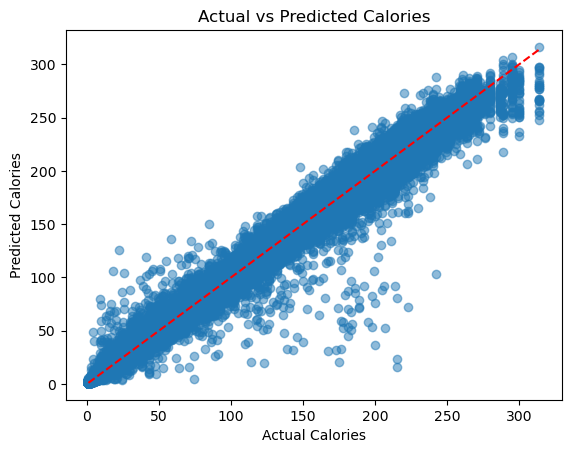

In [ ]:
plt.scatter(train['Calories'], oof_preds, alpha=0.5)
plt.plot([train['Calories'].min(), train['Calories'].max()], [train['Calories'].min(), train['Calories'].max()], color='red', linestyle='--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted Calories')
plt.show()

In [ ]:
final_pred_log = best_weights[0] * pred_cb_adj + best_weights[1] * pred_xgb_adj + best_weights[2] * pred_lgbm_adj

In [ ]:
final_preds = np.expm1(final_pred_log)

In [ ]:
final_preds_clipped = np.clip(final_preds, 1, 314)

In [ ]:
submission['Calories'] = final_preds_clipped
submission.to_csv('submission.csv', index=False)

In [ ]:
'''best_sub = pd.read_csv('best_submission.csv')
best_y = np.log1p(best_sub['Calories'])

v6_sub = pd.read_csv('V6_submission.csv')
v6_y = np.log1p(v6_sub['Calories'])'''

In [ ]:
'''sub_ens = 0.55 * best_y + 0.45 * v6_y'''

In [ ]:
'''final_sub_ens = np.expm1(sub_ens)'''

In [ ]:
'''final_sub_ens_clipped = np.clip(final_sub_ens, 1, 314)'''

In [ ]:
'''submission['Calories'] = final_sub_ens_clipped
submission.to_csv('submission.csv', index=False)'''